In [29]:
# Basic imports
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and scaling
from sklearn.preprocessing import StandardScaler

# Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Dimensionality reduction for visualization
from sklearn.decomposition import PCA


In [30]:
df=pd.read_csv('/Users/sanatwalia/Desktop/Assignments_applications/Player_Segmentation/dataset/player_data.csv')

In [31]:
df.columns

Index(['Unnamed: 0', 'player_id', 'avg_session_time', 'sessions_per_week',
       'last_purchase_amount', 'total_spent', 'level_reached',
       'retention_days', 'churned', 'satisfaction_score', 'bug_reports',
       'has_premium', 'signup_month', 'signup_dayofweek', 'country_Brazil',
       'country_Germany', 'country_India', 'country_Japan', 'country_USA',
       'country_United Kingdom', 'device_Android', 'device_PC', 'device_iOS'],
      dtype='object')

In [32]:
df = df.drop(['Unnamed: 0', 'player_id','bug_reports'], axis=1)


In [33]:
df.columns

Index(['avg_session_time', 'sessions_per_week', 'last_purchase_amount',
       'total_spent', 'level_reached', 'retention_days', 'churned',
       'satisfaction_score', 'has_premium', 'signup_month', 'signup_dayofweek',
       'country_Brazil', 'country_Germany', 'country_India', 'country_Japan',
       'country_USA', 'country_United Kingdom', 'device_Android', 'device_PC',
       'device_iOS'],
      dtype='object')

In [34]:
# List of numerical columns
numerical_columns = [
    'avg_session_time', 'sessions_per_week', 'last_purchase_amount',
    'total_spent', 'level_reached', 'retention_days', 'satisfaction_score', 'has_premium'
]

# Standardize the numerical data
scaler = StandardScaler()
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])


In [35]:
df.isnull().sum()

avg_session_time          0
sessions_per_week         0
last_purchase_amount      0
total_spent               0
level_reached             0
retention_days            0
churned                   0
satisfaction_score        0
has_premium               0
signup_month              1
signup_dayofweek          1
country_Brazil            0
country_Germany           0
country_India             0
country_Japan             0
country_USA               0
country_United Kingdom    0
device_Android            0
device_PC                 0
device_iOS                0
dtype: int64

In [36]:
# Drop rows where 'signup_month' is NaN
df.dropna(subset=['signup_month'], inplace=True)
# Drop rows where 'signup_month' is NaN
df.dropna(subset=['signup_dayofweek'], inplace=True)


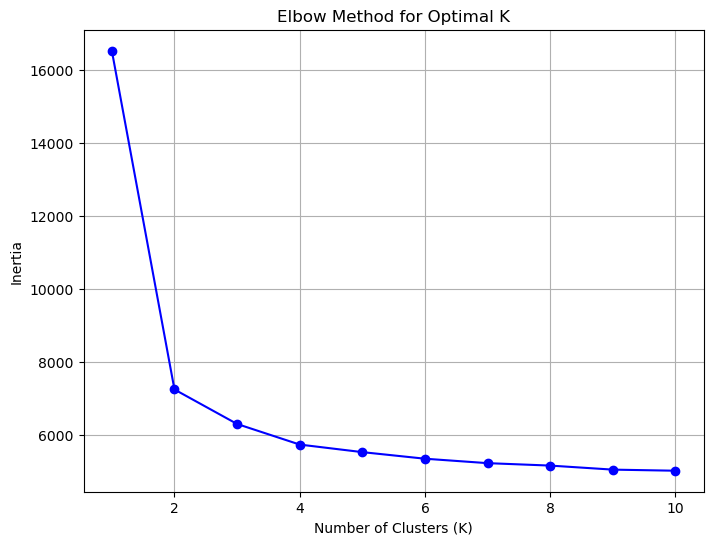

In [37]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Initialize an empty list to store the inertia values for each K
inertia = []

# Test different values of K (e.g., from 1 to 10 clusters)
for k in range(1, 11):  # You can increase the range if needed
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df)  # Fit the model on your scaled data (df)
    inertia.append(kmeans.inertia_)  # Append the inertia (sum of squared distances)

# Plot the Elbow Method graph
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), inertia, marker='o', color='b')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

In [38]:
print("The elbow point is at K=3, which indicates the optimal number of clusters.")

The elbow point is at K=3, which indicates the optimal number of clusters.


In [39]:
kmeans = KMeans(n_clusters=3, random_state=42)

# Fit the KMeans model and predict cluster labels
clusters = kmeans.fit_predict(df)

# Add the cluster labels to your DataFrame
df['Cluster'] = clusters

# Print the cluster centers (to understand the "average" player in each cluster)
print("Cluster Centers:")
print(kmeans.cluster_centers_)


Cluster Centers:
[[ 2.89433351e-02  1.27862878e-01 -4.56660911e-03  3.42699397e-02
  -3.62466242e-02 -3.14640923e-02  2.10227273e-01 -4.31229722e-02
   5.35419273e-02  1.15397727e+01  2.79545455e+00  1.19318182e-01
   1.70454545e-01  2.21590909e-01  1.30681818e-01  2.15909091e-01
   1.42045455e-01  2.67045455e-01  3.69318182e-01  3.63636364e-01]
 [-4.83769991e-02 -1.00706160e-01 -7.37469423e-02  6.78271196e-02
   4.49755028e-02  2.30161502e-04  1.54761905e-01  8.74722378e-02
  -2.44503413e-01  2.57142857e+00  1.36904762e+00  1.07142857e-01
   1.36904762e-01  2.55952381e-01  1.30952381e-01  2.32142857e-01
   1.36904762e-01  3.57142857e-01  2.97619048e-01  3.45238095e-01]
 [ 2.52669187e-02 -4.07067878e-02  8.35517274e-02 -1.02885389e-01
  -4.45837101e-03  3.54585114e-02  1.56250000e-01 -4.49922512e-02
   2.03756779e-01  2.51875000e+00  4.71875000e+00  1.06250000e-01
   9.37500000e-02  2.18750000e-01  1.37500000e-01  3.12500000e-01
   1.31250000e-01  3.37500000e-01  3.81250000e-01  2.8125

In [27]:
df.head()

,avg_session_time,sessions_per_week,last_purchase_amount,total_spent,level_reached,retention_days,churned,satisfaction_score,has_premium,signup_month,...,country_Brazil,country_Germany,country_India,country_Japan,country_USA,country_United Kingdom,device_Android,device_PC,device_iOS,Cluster
0,34.97,4,20.11,66.06,24,131,0,6.0,True,2.0,...,0,0,1,0,0,0,1,0,0,1
1,28.62,4,3.63,40.83,89,49,0,10.0,True,4.0,...,0,0,1,0,0,0,0,1,0,0
2,31.42,4,0.00,142.54,14,9,1,10.0,False,2.0,...,0,0,0,0,1,0,1,0,0,2
3,29.65,5,4.96,15.02,4,2,1,6.0,False,11.0,...,1,0,0,0,0,0,0,0,1,6
4,16.72,7,0.00,2.31,40,82,0,6.0,True,4.0,...,0,0,1,0,0,0,0,0,1,0


In [40]:
df['Cluster'].value_counts()

Cluster
0    176
1    168
2    160
Name: count, dtype: int64

In [41]:
# Optionally, evaluate clustering quality with Silhouette Score
from sklearn.metrics import silhouette_score

score = silhouette_score(df.drop('Cluster', axis=1), clusters)
print(f"Silhouette Score: {score}")

Silhouette Score: 0.2840885461236659


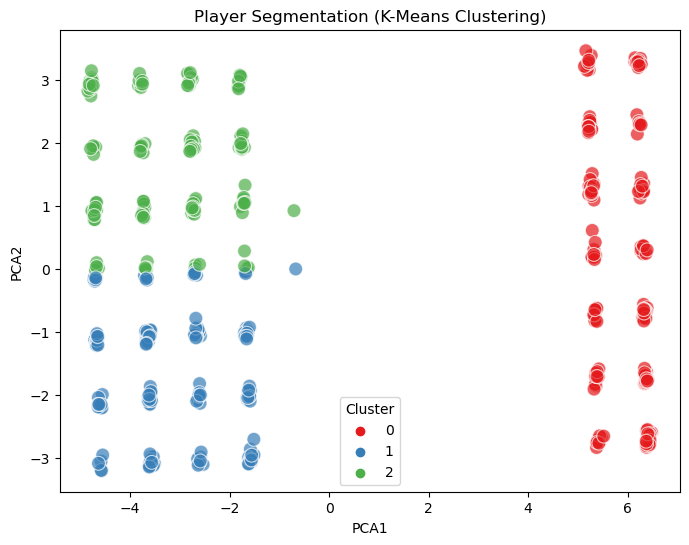

In [42]:
# Reducing dimensions for visualization using PCA
pca = PCA(n_components=2)
pca_components = pca.fit_transform(df.drop('Cluster', axis=1))  # Drop 'Cluster' column for PCA

# Create a DataFrame for the 2D PCA components
pca_df = pd.DataFrame(data=pca_components, columns=['PCA1', 'PCA2'])
pca_df['Cluster'] = clusters  # Add the cluster labels to the PCA DataFrame

# Plotting the clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=pca_df, palette='Set1', s=100, alpha=0.7)
plt.title('Player Segmentation (K-Means Clustering)')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.legend(title='Cluster')
plt.show()

In [44]:
pca.explained_variance_ratio_


array([0.58809273, 0.11927709])